# Step 1: Conduct Exploratory Data Analysis (EDA)

In [34]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df= pd.read_csv('D:/Data Science & Analytics Internship/Phase 2/Task 2 Customer Segmentation Using Unsupervised Learning/Mall_Customers.csv')

In [36]:
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [37]:
#Checking null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [38]:
df.shape

(200, 5)

In [39]:
#df.describe

In [40]:
df.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [41]:
df.duplicated().sum()

0

In [42]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [43]:
#Extracting target columns

X=df.iloc[:,[3,4]].values

In [44]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

# Step 2: Apply K-Means Clustering to segment customers

In [45]:
#Applying elbow method to find optimal number of clusters

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print(wcss)

[400.0, 274.0906128402975, 157.70400815035947, 108.92131661364357, 65.56840815571681, 57.381747460227864, 47.338486736388234, 42.425645549119665, 32.813636941057766, 29.618329582146515]


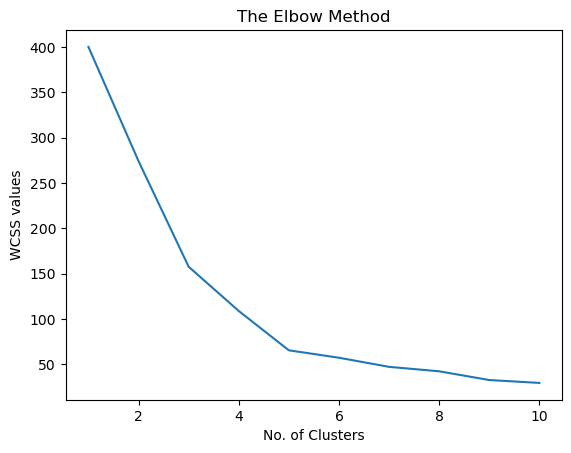

In [18]:
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS values')
plt.show()

In [46]:
#Training a model using k-means

kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=0)

In [47]:
y_kmeans = kmeans_model.fit_predict(X)

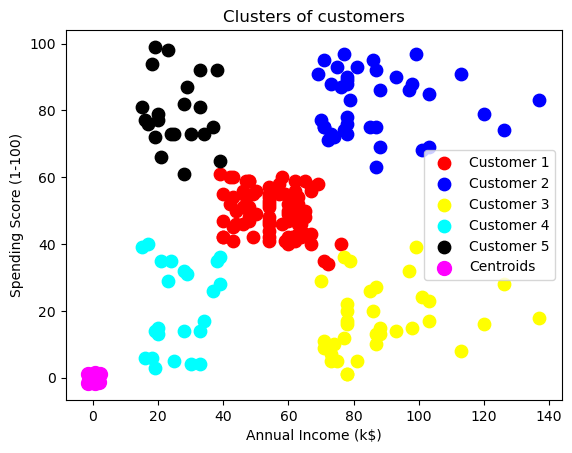

In [48]:
plt.scatter(X[y_kmeans == 0,0], X[y_kmeans == 0,1], s = 80, c = 'red', label = 'Customer 1')
plt.scatter(X[y_kmeans == 1,0], X[y_kmeans == 1,1], s = 80, c = 'blue', label = 'Customer 2')
plt.scatter(X[y_kmeans == 2,0], X[y_kmeans == 2,1], s = 80, c = 'yellow', label = 'Customer 3')
plt.scatter(X[y_kmeans == 3,0], X[y_kmeans == 3,1], s = 80, c = 'cyan', label = 'Customer 4')
plt.scatter(X[y_kmeans == 4,0], X[y_kmeans == 4,1], s = 80, c = 'black', label = 'Customer 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = "magenta", label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [49]:
#Add cluster labels to your dataset

df_clusters = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])]) 
df_clusters['Cluster'] = y_kmeans 
print(df_clusters.head())

   feature_0  feature_1  Cluster
0         15         39        3
1         15         81        4
2         16          6        3
3         16         77        4
4         17         40        3


# Step 3: Using PCA to visualize the clusters

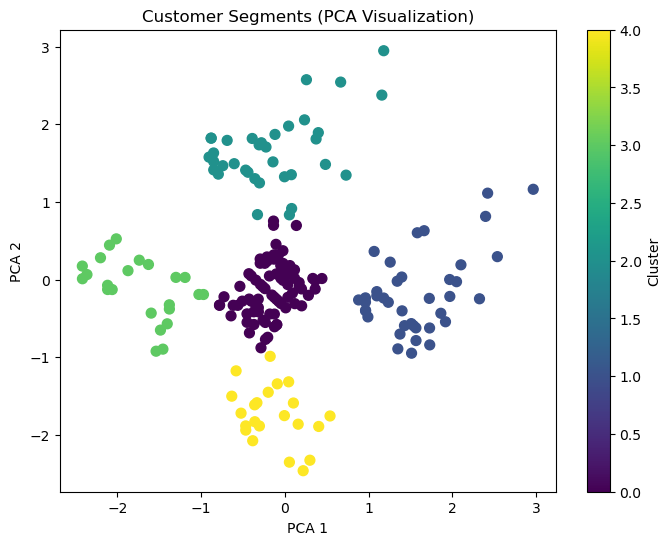

In [50]:
# STEP 5: Visualize Clusters with PCA
from sklearn.decomposition import PCA

# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans, cmap='viridis', s=50)
plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

In [51]:
df['Cluster'] = y_kmeans

# Summarize cluster profiles
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()
print(cluster_summary)

# counting customers per cluster
print(df['Cluster'].value_counts())

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 88.200000               17.114286
3                 26.304348               20.913043
4                 25.727273               79.363636
Cluster
0    81
1    39
2    35
3    23
4    22
Name: count, dtype: int64


# Step 4: Suggest relevant marketing strategies for each identified segment

In [52]:
# Define strategies based on cluster profiles
strategies = {
    0: {"Customer Type": "Young, low income, moderate spending",
        "Strategy": "Budget-friendly offers, student discounts, loyalty points"},
    1: {"Customer Type": "Middle-aged, high income, high spending",
        "Strategy": "Premium products, VIP memberships, exclusive events"},
    2: {"Customer Type": "Young professionals, high income, low spending",
        "Strategy": "Personalized recommendations, upselling, targeted ads"},
    3: {"Customer Type": "Older customers, moderate income, low spending",
        "Strategy": "Trust-building campaigns, family bundles, value packs"},
    4: {"Customer Type": "Young adults, moderate income, high spending",
        "Strategy": "Trendy products, social media campaigns, influencer marketing"}
}

# Displaying strategies
for cluster, info in strategies.items():
    print(f"Cluster {cluster}: {info['Customer Type']} → {info['Strategy']}")

Cluster 0: Young, low income, moderate spending → Budget-friendly offers, student discounts, loyalty points
Cluster 1: Middle-aged, high income, high spending → Premium products, VIP memberships, exclusive events
Cluster 2: Young professionals, high income, low spending → Personalized recommendations, upselling, targeted ads
Cluster 3: Older customers, moderate income, low spending → Trust-building campaigns, family bundles, value packs
Cluster 4: Young adults, moderate income, high spending → Trendy products, social media campaigns, influencer marketing
